## 数据集构造说明

本题的原始数据来自 MegaDepth 测试集。老师提供的 `demo.ipynb` 只能处理一对图像：先通过 `MegaDepthAPI` 读取一组图像对，再通过 `SPFeatAPI` 提取两张图像之间的候选匹配点及其深度特征，最后利用 MegaDepth 中的真实几何信息生成 0/1 标签，其中 `0` 表示错误匹配，`1` 表示正确匹配。

为了形成可用于机器学习训练的数据集，本文没有只使用单对图像，而是选取前100对图像进行批量处理。对每一对图像，程序依次完成以下步骤：读取图像对、提取匹配点和深度特征、计算真实标签、构造特征矩阵，并将所有图像对得到的匹配点样本合并。需要注意的是，这里的“100对图像”并不等于100个机器学习样本。每一对图像会产生数百到上千个匹配点对，每一个匹配点对才是一个监督学习样本。

在特征构造方面，每个样本对应一组候选匹配点对。自变量包括匹配点坐标、坐标位移、欧氏距离、方向角、归一化坐标、局部描述子差异、拓扑特征差异、余弦相似度、置信度和综合得分等，共273个特征。应变量为该匹配点对的真实类别标签：`0` 为错误匹配，`1` 为正确匹配。最终得到的数据集规模为 `X_all shape = (87052, 273)`，`y_all shape = (87052,)`，其中正确匹配样本72276个，错误匹配样本14776个。

以下是构造数据集的代码，已在终端中运行过
# 路径设置
MYXFEAT_DIR = '/mnt/myxfeat'
DATA_ROOT = '/mnt/megadepth_test_1500'
OUT_PATH = '/mnt/match_dataset_100.npz'

sys.path.append(MYXFEAT_DIR)
os.chdir(MYXFEAT_DIR)

from xfeat_api import SPFeatAPI
from megadepth_api import MegaDepthAPI


def build_features_from_res(res, labels=None, img0=None, img1=None):
    """
    根据 XFeat 输出结果 res 构造机器学习特征矩阵 X。
    每一行对应一组匹配点对。
    """
    pts1 = res['pts1']
    pts2 = res['pts2']
    desc1 = res['desc1']
    desc2 = res['desc2']
    topo1 = res['topo1']
    topo2 = res['topo2']

    cossim = res['cossim'].reshape(-1, 1)
    confidence = res['confidence'].reshape(-1, 1)
    ultimate_score = res['ultimate_score'].reshape(-1, 1)

    # 坐标与几何特征
    x1 = pts1[:, 0].reshape(-1, 1)
    y1 = pts1[:, 1].reshape(-1, 1)
    x2 = pts2[:, 0].reshape(-1, 1)
    y2 = pts2[:, 1].reshape(-1, 1)

    dx = x2 - x1
    dy = y2 - y1
    dist = np.sqrt(dx ** 2 + dy ** 2)
    angle = np.arctan2(dy, dx)

    geo_features = [x1, y1, x2, y2, dx, dy, dist, angle]
    geo_names = ['x1', 'y1', 'x2', 'y2', 'dx', 'dy', 'dist', 'angle']

    # 归一化坐标
    if img0 is not None and img1 is not None:
        h0, w0 = img0.shape[:2]
        h1, w1 = img1.shape[:2]

        x1_norm = x1 / w0
        y1_norm = y1 / h0
        x2_norm = x2 / w1
        y2_norm = y2 / h1

        geo_features += [x1_norm, y1_norm, x2_norm, y2_norm]
        geo_names += ['x1_norm', 'y1_norm', 'x2_norm', 'y2_norm']

    geo_features = np.hstack(geo_features)

    # 局部描述子差异特征
    desc_abs_diff = np.abs(desc1 - desc2)
    desc_mul = desc1 * desc2
    desc_l2 = np.sqrt(np.sum((desc1 - desc2) ** 2, axis=1)).reshape(-1, 1)

    # 拓扑特征差异
    topo_abs_diff = np.abs(topo1 - topo2)
    topo_mul = topo1 * topo2
    topo_l2 = np.sqrt(np.sum((topo1 - topo2) ** 2, axis=1)).reshape(-1, 1)

    # 分数类特征
    score_features = np.hstack([cossim, confidence, ultimate_score])

    # 拼接所有特征
    X = np.hstack([
        geo_features,
        desc_abs_diff,
        desc_mul,
        desc_l2,
        topo_abs_diff,
        topo_mul,
        topo_l2,
        score_features
    ])

    feature_names = []
    feature_names += geo_names
    feature_names += [f'desc_abs_diff_{i}' for i in range(desc_abs_diff.shape[1])]
    feature_names += [f'desc_mul_{i}' for i in range(desc_mul.shape[1])]
    feature_names += ['desc_l2']
    feature_names += [f'topo_abs_diff_{i}' for i in range(topo_abs_diff.shape[1])]
    feature_names += [f'topo_mul_{i}' for i in range(topo_mul.shape[1])]
    feature_names += ['topo_l2']
    feature_names += ['cossim', 'confidence', 'ultimate_score']

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if labels is not None:
        y = labels.astype(np.int64)
        return X, y, feature_names
    else:
        return X, feature_names


if RUN_BUILD_DATASET:
    net = SPFeatAPI('./weights/xfeat_default_160000.pth')
    md = MegaDepthAPI('./assets/megadepth_1500.json', DATA_ROOT)

    X_list = []
    y_list = []
    pair_ids = []
    feature_names = None

    num_pairs = 100

    for idx in range(num_pairs):
        t0 = time.time()

        img0, img1, data = md.get_data_by_idx(idx)
        res = net.extract_and_match(img0, img1)

        pts0, pts1 = res['pts1'], res['pts2']
        labels = md.compute_01_labels(pts0, pts1, data)

        X, y, feature_names = build_features_from_res(res, labels, img0, img1)

        X_list.append(X)
        y_list.append(y)
        pair_ids.extend([idx] * len(y))

        print(
            f"[OK] idx={idx}, 匹配点={len(y)}, "
            f"正样本={np.sum(y == 1)}, 负样本={np.sum(y == 0)}, "
            f"用时={time.time() - t0:.2f}s"
        )

        gc.collect()

    X_all = np.vstack(X_list).astype(np.float32)
    y_all = np.concatenate(y_list).astype(np.int64)
    pair_ids = np.array(pair_ids, dtype=np.int64)

    np.savez_compressed(
        OUT_PATH,
        X=X_all,
        y=y_all,
        pair_ids=pair_ids,
        feature_names=np.array(feature_names)
    )

    print("数据集已保存到:", OUT_PATH)
    print("X_all shape:", X_all.shape)
    print("y_all shape:", y_all.shape)
    print("正样本数量:", np.sum(y_all == 1))
    print("负样本数量:", np.sum(y_all == 0))

In [2]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

# 1. 读取已经构造好的100对图像数据集
npz_data = np.load('/mnt/match_dataset_100.npz', allow_pickle=True)

X_all = npz_data['X']
y_all = npz_data['y']
feature_names = npz_data['feature_names']
pair_ids = npz_data['pair_ids']

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("特征数量:", len(feature_names))
print("正样本数量:", np.sum(y_all == 1))
print("负样本数量:", np.sum(y_all == 0))

# 2. 按图像对划分训练集和测试集
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_all, y_all, groups=pair_ids))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("训练集正样本数量:", np.sum(y_train == 1))
print("训练集负样本数量:", np.sum(y_train == 0))
print("测试集正样本数量:", np.sum(y_test == 1))
print("测试集负样本数量:", np.sum(y_test == 0))

print("训练集图像对数量:", len(np.unique(pair_ids[train_idx])))
print("测试集图像对数量:", len(np.unique(pair_ids[test_idx])))

X_all shape: (87052, 273)
y_all shape: (87052,)
特征数量: 273
正样本数量: 72276
负样本数量: 14776
X_train: (70467, 273)
X_test: (16585, 273)
训练集正样本数量: 58612
训练集负样本数量: 11855
测试集正样本数量: 13664
测试集负样本数量: 2921
训练集图像对数量: 80
测试集图像对数量: 20


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_rf = rf_model.predict(X_test)

print("随机森林模型结果")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['错误匹配 0', '正确匹配 1'],
    digits=4
))

print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_rf))

随机森林模型结果
Accuracy: 0.869339764847754

              precision    recall  f1-score   support

      错误匹配 0     0.8378    0.3201    0.4632      2921
      正确匹配 1     0.8716    0.9868    0.9256     13664

    accuracy                         0.8693     16585
   macro avg     0.8547    0.6534    0.6944     16585
weighted avg     0.8657    0.8693    0.8442     16585

混淆矩阵：
[[  935  1986]
 [  181 13483]]


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=512,
        learning_rate_init=0.001,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(batch_size=512, early_stopping=True,
                               hidden_layer_sizes=(128, 64), max_iter=80,
                               random_state=42))])

In [7]:
y_pred_mlp = mlp_model.predict(X_test)

print("MLP 模型结果")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print()
print(classification_report(
    y_test,
    y_pred_mlp,
    target_names=['错误匹配 0', '正确匹配 1'],
    digits=4
))

print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_mlp))

MLP 模型结果
Accuracy: 0.8760928549894483

              precision    recall  f1-score   support

      错误匹配 0     0.7797    0.4132    0.5402      2921
      正确匹配 1     0.8860    0.9750    0.9284     13664

    accuracy                         0.8761     16585
   macro avg     0.8329    0.6941    0.7343     16585
weighted avg     0.8673    0.8761    0.8600     16585

混淆矩阵：
[[ 1207  1714]
 [  341 13323]]


In [8]:
import joblib

joblib.dump(rf_model, '/mnt/rf_match_classifier.pkl')
joblib.dump(mlp_model, '/mnt/mlp_match_classifier.pkl')

print("模型已保存。")

模型已保存。


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logit_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    ))
])

logit_model.fit(X_train, y_train)

y_pred_logit = logit_model.predict(X_test)

print("逻辑斯蒂回归模型结果")
print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print()

print(classification_report(
    y_test,
    y_pred_logit,
    target_names=['错误匹配 0', '正确匹配 1'],
    digits=4
))

print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred_logit))

逻辑斯蒂回归模型结果
Accuracy: 0.8064516129032258

              precision    recall  f1-score   support

      错误匹配 0     0.4679    0.7200    0.5672      2921
      正确匹配 1     0.9323    0.8249    0.8754     13664

    accuracy                         0.8065     16585
   macro avg     0.7001    0.7725    0.7213     16585
weighted avg     0.8505    0.8065    0.8211     16585

混淆矩阵：
[[ 2103   818]
 [ 2392 11272]]


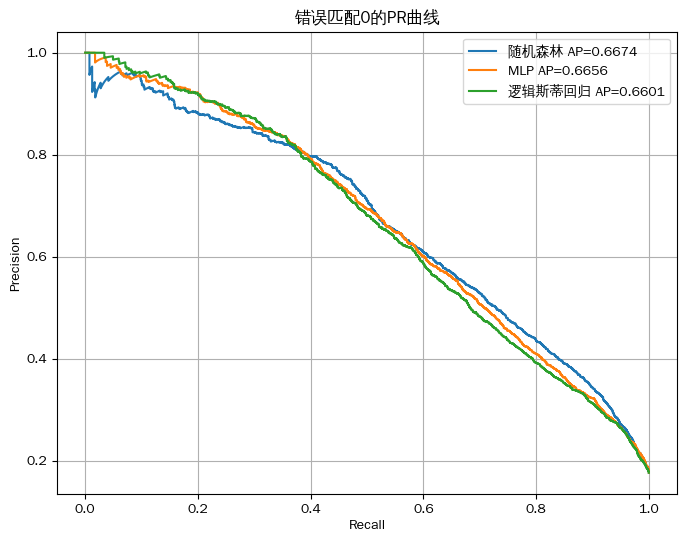

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Noto Sans CJK SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def get_proba_for_class(model, X, target_class):
    proba = model.predict_proba(X)
    classes = model.classes_
    class_index = list(classes).index(target_class)
    return proba[:, class_index]

# 将错误匹配0作为关注对象
y_test_error = (y_test == 0).astype(int)

rf_score_error = get_proba_for_class(rf_model, X_test, 0)
mlp_score_error = get_proba_for_class(mlp_model, X_test, 0)
logit_score_error = get_proba_for_class(logit_model, X_test, 0)

precision_rf, recall_rf, _ = precision_recall_curve(y_test_error, rf_score_error)
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test_error, mlp_score_error)
precision_logit, recall_logit, _ = precision_recall_curve(y_test_error, logit_score_error)

ap_rf = average_precision_score(y_test_error, rf_score_error)
ap_mlp = average_precision_score(y_test_error, mlp_score_error)
ap_logit = average_precision_score(y_test_error, logit_score_error)

plt.figure(figsize=(8, 6))

plt.plot(recall_rf, precision_rf, label=f'随机森林 AP={ap_rf:.4f}')
plt.plot(recall_mlp, precision_mlp, label=f'MLP AP={ap_mlp:.4f}')
plt.plot(recall_logit, precision_logit, label=f'逻辑斯蒂回归 AP={ap_logit:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('错误匹配0的PR曲线')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
import joblib

joblib.dump(mlp_model, '/mnt/mlp_match_classifier.pkl')
print("MLP模型已保存到 /mnt/mlp_match_classifier.pkl")

MLP模型已保存到 /mnt/mlp_match_classifier.pkl


## 基于MLP模型的匹配点过滤与可视化

前面已经完成了三种分类模型的训练与评价。由于本题关注的核心不是单纯的整体准确率，而是在保留大部分正确匹配点的前提下尽量去除错误匹配点，因此需要进一步把模型结果放回图像匹配场景中检验。综合比较后，MLP模型在正确匹配1保持较高召回率的同时，对错误匹配0的召回率更高，更适合作为最终的匹配点过滤模型。

下面选取测试集中的一组图像对，先展示原始匹配结果，再利用MLP模型预测每个匹配点对的类别，并只保留预测为正确匹配1的点对。通过比较过滤前后的可视化结果，可以更直观地观察红色错误匹配线是否减少，以及正确匹配点是否得到较好保留。

In [13]:
%cd /mnt/myxfeat


from xfeat_api import SPFeatAPI
from megadepth_api import MegaDepthAPI

net = SPFeatAPI('./weights/xfeat_default_160000.pth')
md = MegaDepthAPI('./assets/megadepth_1500.json', '/mnt/megadepth_test_1500')

/root/miniconda3/envs/myconda/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/mnt/myxfeat
loading weights from: ./weights/xfeat_default_160000.pth


In [14]:
import numpy as np
from collections import Counter

# 测试集中出现过的图像对编号
test_pair_ids = np.unique(pair_ids[test_idx])

# 统计每个测试图像对中的错误匹配数量
pair_error_count = {}

for pid in test_pair_ids:
    mask = pair_ids == pid
    pair_error_count[pid] = np.sum(y_all[mask] == 0)

# 选择错误匹配数量最多的一组图像对
vis_pair_id = max(pair_error_count, key=pair_error_count.get)

print("用于可视化的图像对编号:", vis_pair_id)
print("该图像对错误匹配数量:", pair_error_count[vis_pair_id])

用于可视化的图像对编号: 53
该图像对错误匹配数量: 192


In [16]:
%cd /mnt/myxfeat

import sys
import joblib
import numpy as np

sys.path.append('/mnt/myxfeat')

from build_dataset import build_features_from_res

mlp_model = joblib.load('/mnt/mlp_match_classifier.pkl')

print("特征构造函数和MLP模型均已准备好")

/mnt/myxfeat
特征构造函数和MLP模型均已准备好


/root/miniconda3/envs/myconda/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [17]:
# 读取图像对
img0_vis, img1_vis, data_vis = md.get_data_by_idx(int(vis_pair_id))

# 提取匹配点和深度特征
res_vis = net.extract_and_match(img0_vis, img1_vis)

pts0_vis, pts1_vis = res_vis['pts1'], res_vis['pts2']

# 获取真实0/1标签
labels_vis = md.compute_01_labels(pts0_vis, pts1_vis, data_vis)

# 构造与训练阶段相同的特征矩阵
X_vis, y_vis, _ = build_features_from_res(res_vis, labels_vis, img0_vis, img1_vis)

# 使用MLP模型预测
y_pred_vis = mlp_model.predict(X_vis)

print("原始匹配点数量:", len(y_vis))
print("原始正确匹配数量:", np.sum(y_vis == 1))
print("原始错误匹配数量:", np.sum(y_vis == 0))

print("模型预测保留的匹配点数量:", np.sum(y_pred_vis == 1))
print("模型预测删除的匹配点数量:", np.sum(y_pred_vis == 0))

原始匹配点数量: 967
原始正确匹配数量: 775
原始错误匹配数量: 192
模型预测保留的匹配点数量: 876
模型预测删除的匹配点数量: 91


In [18]:
# 预测为1的点对会被保留
keep_mask = (y_pred_vis == 1)

# 过滤后的匹配点和标签
pts0_keep = pts0_vis[keep_mask]
pts1_keep = pts1_vis[keep_mask]
labels_keep = labels_vis[keep_mask]

# 统计过滤效果
original_total = len(labels_vis)
original_wrong = np.sum(labels_vis == 0)
original_right = np.sum(labels_vis == 1)

kept_total = len(labels_keep)
kept_wrong = np.sum(labels_keep == 0)
kept_right = np.sum(labels_keep == 1)

removed_total = original_total - kept_total
removed_wrong = original_wrong - kept_wrong
removed_right = original_right - kept_right

print("原始匹配点总数:", original_total)
print("原始错误匹配数量:", original_wrong)
print("原始正确匹配数量:", original_right)
print()

print("过滤后保留匹配点数量:", kept_total)
print("过滤后剩余错误匹配数量:", kept_wrong)
print("过滤后剩余正确匹配数量:", kept_right)
print()

print("被删除的匹配点数量:", removed_total)
print("成功删除的错误匹配数量:", removed_wrong)
print("误删的正确匹配数量:", removed_right)
print()

print("错误匹配删除比例:", removed_wrong / original_wrong)
print("正确匹配保留比例:", kept_right / original_right)

原始匹配点总数: 967
原始错误匹配数量: 192
原始正确匹配数量: 775

过滤后保留匹配点数量: 876
过滤后剩余错误匹配数量: 115
过滤后剩余正确匹配数量: 761

被删除的匹配点数量: 91
成功删除的错误匹配数量: 77
误删的正确匹配数量: 14

错误匹配删除比例: 0.4010416666666667
正确匹配保留比例: 0.9819354838709677


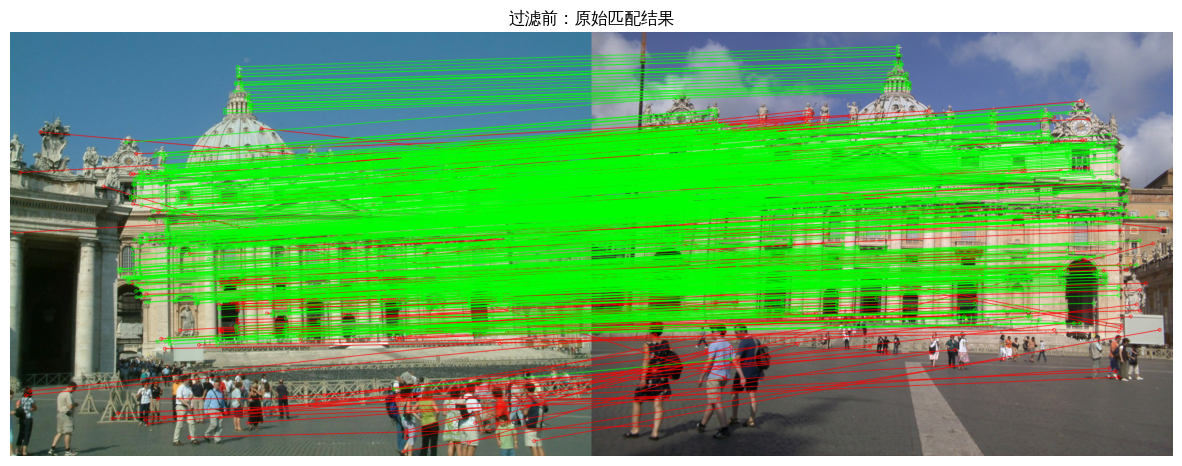

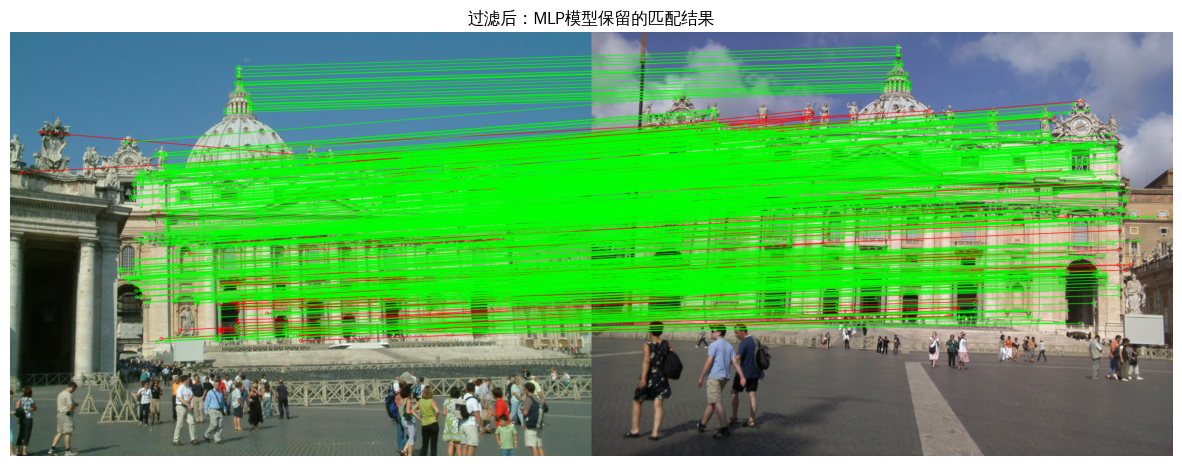

In [20]:
import matplotlib.pyplot as plt

# 尽量设置中文字体，如果仍有字体问题，可以把标题改成英文
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Noto Sans CJK SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 过滤前
vis_before = md.draw_matches(
    img0_vis, img1_vis,
    pts0_vis, pts1_vis,
    labels_vis
)

plt.figure(figsize=(15, 8))
plt.imshow(vis_before[:, :, ::-1])
plt.title("过滤前：原始匹配结果")
plt.axis('off')
plt.show()

# 过滤后
vis_after = md.draw_matches(
    img0_vis, img1_vis,
    pts0_keep, pts1_keep,
    labels_keep
)

plt.figure(figsize=(15, 8))
plt.imshow(vis_after[:, :, ::-1])
plt.title("过滤后：MLP模型保留的匹配结果")
plt.axis('off')
plt.show()

本题最终选择MLP模型作为错误匹配点的过滤模型。选择MLP的原因在于，本题的目标并不是单纯追求整体准确率，而是在尽可能保留更多正确匹配点的前提下，尽可能减少红色错误匹配线。根据测试集结果，MLP模型的整体准确率为0.8761，略高于随机森林模型的0.8693。同时，MLP对错误匹配0的召回率为0.4132，高于随机森林的0.3201，说明它能够识别出更多错误匹配点。虽然MLP误删的正确匹配点略多，但正确匹配1的召回率仍达到0.9750，说明大部分正确匹配仍然被保留下来。

在可视化实验中，本文将MLP模型预测为1的匹配点视为保留点，预测为0的匹配点视为需要过滤的错误匹配点。通过比较过滤前后的匹配图可以看到，过滤后红色错误匹配线明显减少，同时仍然保留了大部分绿色正确匹配线。这说明基于深度特征训练得到的二分类模型可以作为图像匹配后的初步筛选工具，用于提高匹配点对的整体质量。